In [ ]:
import pyart
import matplotlib.pyplot as plt
import os
from netCDF4 import num2date
import cartopy
import numpy as np
import pandas as pd
import glob
from datetime import datetime

##############################################
# METR 5683 - Weather Radar Applications
# Final Project
# Author: Jacob Widanski
# Date: 9 May 2026
##############################################

In [41]:
# Radar test
radar_dir = r"C:\Users\wida0001\Documents\Courses\Weather Radar Applications\Data\NEXRAD"
#filepath=r"C:\Users\wida0001\Downloads\NOP420130519_213700_V06\NOP420130519_213700_V06"

file1=r"KTLX20130530_214603_V06"
file2=r"DAN120130530_214838_V06"
file3=r"TOKC20230419_225611_V08"


KTLX = pyart.io.read(os.path.join(radar_dir, file1))
KCRI = pyart.io.read(os.path.join(radar_dir, file2))
TOKC = pyart.io.read(os.path.join(radar_dir, file3))

KTLX.info()
list(KTLX.fields)

altitude:
	data: <ndarray of type: float64 and shape: (1,)>
	long_name: Altitude
	standard_name: Altitude
	units: meters
	positive: up
altitude_agl: None
antenna_transition: None
azimuth:
	data: <ndarray of type: float64 and shape: (8280,)>
	units: degrees
	standard_name: beam_azimuth_angle
	long_name: azimuth_angle_from_true_north
	axis: radial_azimuth_coordinate
	comment: Azimuth of antenna relative to true north
elevation:
	data: <ndarray of type: float32 and shape: (8280,)>
	units: degrees
	standard_name: beam_elevation_angle
	long_name: elevation_angle_from_horizontal_plane
	axis: radial_elevation_coordinate
	comment: Elevation of antenna relative to the horizontal plane
fields:
	spectrum_width:
		data: <ndarray of type: float32 and shape: (8280, 1832)>
		units: meters_per_second
		standard_name: doppler_spectrum_width
		long_name: Spectrum Width
		valid_max: 63.0
		valid_min: -63.5
		coordinates: elevation azimuth range
		_FillValue: -9999.0
	cross_correlation_ratio:
		data: <nda

['spectrum_width',
 'cross_correlation_ratio',
 'differential_phase',
 'velocity',
 'differential_reflectivity',
 'reflectivity']

In [42]:
print('KTLX has ', KTLX.range['data'].shape, ' gates')
print('KTLX has ', KTLX.azimuth['data'].shape, ' gates')
print('Units of time is ', KTLX.time['units'])
print('Latitude is',KTLX.latitude['data'])
print('Longitude is',KTLX.longitude['data'])
print('Radar name is',KTLX.metadata['instrument_name'])
print('Collection started at ', num2date(KTLX.time['data'][0],KTLX.time['units'] ))
print('Collection ended at ', num2date(KTLX.time['data'][-1],KTLX.time['units'] ))

KTLX has  (1832,)  gates
KTLX has  (8280,)  gates
Units of time is  seconds since 2013-05-30T21:46:03Z
Latitude is [35.3330574]
Longitude is [-97.27748108]
Radar name is KTLX
Collection started at  2013-05-30 21:46:03.809000
Collection ended at  2013-05-30 21:50:31.023000


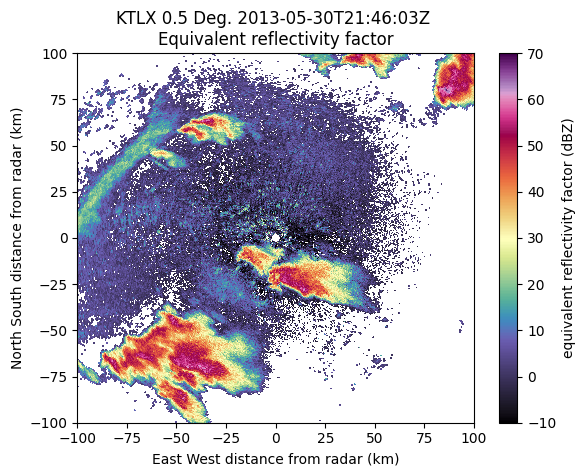

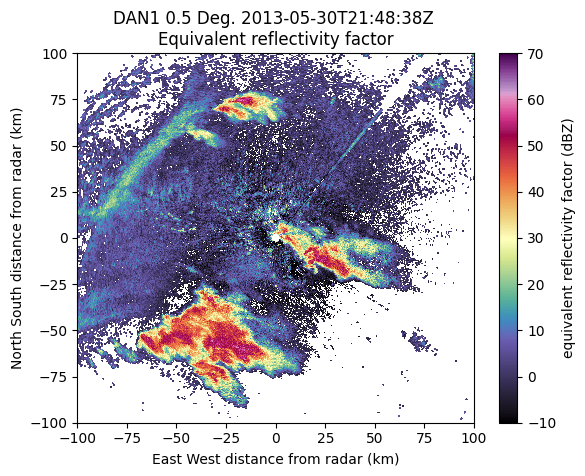

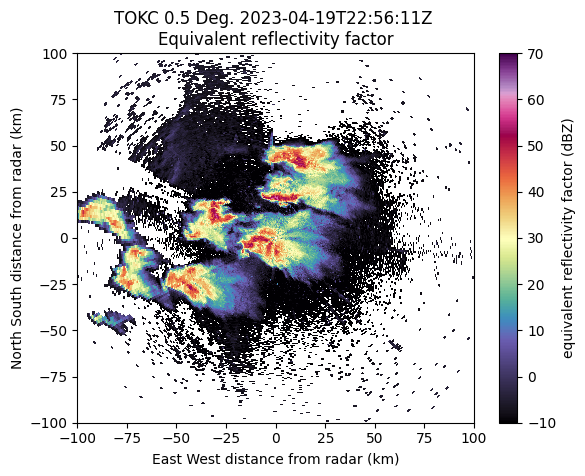

In [43]:
#Initialize a Display object
display1 = pyart.graph.RadarDisplay(KTLX)

display1.plot("reflectivity", #Field Name
    0, #Scan Number
    vmin=-10, #Minimum value to display
    vmax=70, #Maximum value to display
    cmap='ChaseSpectral') #Set colormap
display1.set_limits((-100,100),(-100,100)) #Set limits
plt.show()

#Initialize a Display object
display2 = pyart.graph.RadarDisplay(KCRI)

display2.plot("reflectivity", #Field Name
    0, #Scan Number
    vmin=-10, #Minimum value to display
    vmax=70, #Maximum value to display
    cmap='ChaseSpectral') #Set colormap
display2.set_limits((-100,100),(-100,100)) #Set limits
plt.show()

display3 = pyart.graph.RadarDisplay(TOKC)

display3.plot("reflectivity", #Field Name
    0, #Scan Number
    vmin=-10, #Minimum value to display
    vmax=70, #Maximum value to display
    cmap='ChaseSpectral') #Set colormap
display3.set_limits((-100,100),(-100,100)) #Set limits
plt.show()

In [44]:
# Create plot depicting all SHAVE and Storm Data reports within the radar domain (with lines depicting the spatial domain for DDA)
# Hail report database:
# * SHAVE (2013-2015; 1)
# * Storm Data (2013-2025; 2)
# * mPing (3) / Storm Data (Elmore et al. 2022; 2013-2020)

# 1. Curate hail reports database into a single CSV
base_dir = r"C:\Users\wida0001\Documents\Courses\Weather Radar Applications\Data\Project"

### SHAVE ###
SHAVE_reports = pd.read_csv(os.path.join(base_dir, 'SHAVE.csv'))

# Filter to OUN
SHAVE_reports = SHAVE_reports[SHAVE_reports['cwa'] == 'OUN'] 

# Use measured max ('max meas') if available, otherwise use estimated max ('max est')
SHAVE_reports['max_diameter_mm'] = SHAVE_reports.apply(lambda row: row['max meas'] if not pd.isna(row['max meas']) else row['max est'], axis=1)
SHAVE_reports['max_diameter_mm'] = SHAVE_reports['max_diameter_mm'] * 25.4 # Convert inches to mm

# Use mean time if (end time - start time) > 0
start_datetimes = pd.to_datetime(SHAVE_reports['start_datetime'])
end_datetimes = pd.to_datetime(SHAVE_reports['end_datetime'])

time_deltas = end_datetimes - start_datetimes
mean_times = start_datetimes + time_deltas / 2
SHAVE_reports['time'] = mean_times

SHAVE_reports = SHAVE_reports[SHAVE_reports['time'].dt.year >= 2013] # Temporal filter

SHAVE_reports['source'] = 1

# Keep core columns
shave_columns = ['time', 'lat', 'lon', 'max_diameter_mm', 'source']
SHAVE_reports = SHAVE_reports[shave_columns].sort_values('time').reset_index(drop=True)
print("SHAVE: ", SHAVE_reports.head())

### mPing (Elmore et al. 2022) ###
# source = 1 for mPing, 2 for Storm Data
mping = pd.read_csv(os.path.join(base_dir, 'mPING_Storm_Data.csv'))
mping = mping[mping['source'] == 1] # Filter to mPing reports only
mping['source'] = 3 # Update source to 3 for mPing

# Fix observation time
mping['obtime'] = mping['obtime'].str.replace(' AM', '')
mping['time'] = pd.to_datetime(mping['obtime'], format='%m/%d/%Y %H:%M:%S')
mping.rename(columns={'hailsize.mm': 'max_diameter_mm'}, inplace=True)

columns = ['time', 'lat', 'lon', 'max_diameter_mm', 'source']
mping = mping[columns].sort_values('time').reset_index(drop=True)
print("mPing: ", mping.head())

### Storm Data ###
# Concatenate all years (2013-2025)
storm_data = glob.glob(os.path.join(base_dir, 'StormEvents_details-ftp_v1.0_d20*.csv'))
storm_data = pd.concat((pd.read_csv(file) for file in storm_data), ignore_index=True)

# Filter by OUN and hail events
storm_data = storm_data[(storm_data['WFO'] == 'OUN') & (storm_data['EVENT_TYPE'] == 'Hail')]

# Convert times from local time to UTC (+6)
storm_data['time'] = pd.to_datetime(storm_data['BEGIN_DATE_TIME']) + pd.Timedelta(hours=6)

storm_data.rename(columns={'BEGIN_LAT': 'lat', 'BEGIN_LON': 'lon', 'MAGNITUDE': 'max_diameter_mm'}, inplace=True)
storm_data['max_diameter_mm'] = storm_data['max_diameter_mm'] * 25.4 # Convert inches to mm
storm_data['source'] = 2

columns = ['time', 'lat', 'lon', 'max_diameter_mm', 'source']
storm_data = storm_data[columns].sort_values('time').reset_index(drop=True)
print("Storm Data: ", storm_data.head())

### Combine all reports into a single DataFrame ###
OUN_hail = pd.concat([SHAVE_reports, mping, storm_data], ignore_index=True).sort_values('time').reset_index(drop=True)
OUN_hail = OUN_hail[OUN_hail['max_diameter_mm'] >= 0] # Remove negative values
print("All reports: ", OUN_hail.head())
OUN_hail.to_csv(os.path.join(base_dir, 'OUN_hail_reports_2013_2025.csv'), index=False)

SHAVE:                   time        lat        lon  max_diameter_mm  source
0 2013-03-29 12:10:00  35.553487 -97.798472           22.352       1
1 2013-03-29 23:22:00  35.578510 -97.883130           44.450       1
2 2013-03-29 23:50:00  35.565126 -97.771114           31.750       1
3 2013-03-29 23:50:00  35.585810 -97.849557           44.450       1
4 2013-03-29 23:50:00  35.579194 -97.816756           25.400       1
mPing:                   time        lat         lon  max_diameter_mm  source
0 2013-01-11 23:23:00  42.323200 -122.837670            25.40       3
1 2013-01-12 21:13:00  35.268220  -95.575030             6.35       3
2 2013-01-13 04:07:00  33.087505  -97.050255             6.35       3
3 2013-01-13 04:17:00  33.177700  -96.909070             6.35       3
4 2013-01-13 19:41:00  30.699120  -97.720410             6.35       3
Storm Data:                   time    lat    lon  max_diameter_mm  source
0 2013-01-29 11:10:00  35.51 -98.97             25.4       2
1 2013-01-29 11

[35.2474]
[-97.5395]
{'KTLX': (35.33305740356445, -97.27748107910156), 'KCRI': (35.23833465576172, -97.45999908447266)}


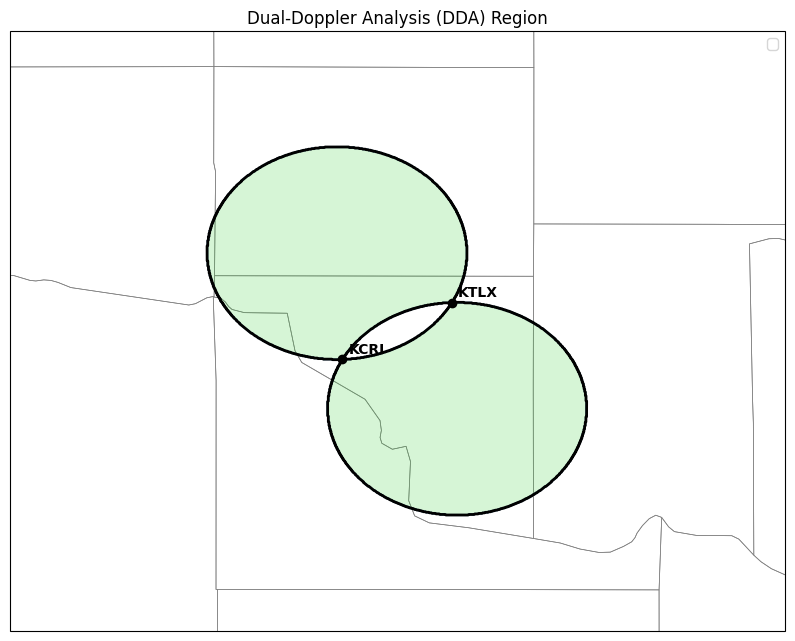

In [45]:
### Calculate region of dual-Doppler coverage (lobe) ###

from pyproj import Proj, Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
print(TOKC.latitude['data'])
print(TOKC.longitude['data'])

# Update TOKC location
TOKC.latitude['data'] = np.array([35.276095099831174])
TOKC.longitude['data'] = np.array([-97.50997083450969])

# ---------------------------
# 1) Radar locations
# ---------------------------
radars = {
    "KTLX": (float(KTLX.latitude["data"][0]), float(KTLX.longitude["data"][0])),
    "KCRI": (float(KCRI.latitude["data"][0]), float(KCRI.longitude["data"][0])),
    #"TOKC": (float(TOKC.latitude["data"][0]), float(TOKC.longitude["data"][0])),
}

print(radars)

# Projection center = mean of radar locations
center_lat = np.mean([v[0] for v in radars.values()])
center_lon = np.mean([v[1] for v in radars.values()])
proj = Proj(proj="aeqd", lat_0=center_lat, lon_0=center_lon, datum="WGS84")
transformer = Transformer.from_proj("epsg:4326", proj, always_xy=True)

# Convert radars to projected x/y (meters)
radar_xy = {}
for name, (lat, lon) in radars.items():
    x, y = transformer.transform(lon, lat)
    radar_xy[name] = (x, y)

# ---------------------------
# 2) Build grid (use 1000 for true 1-km spacing)
# ---------------------------
xs = [xy[0] for xy in radar_xy.values()]
ys = [xy[1] for xy in radar_xy.values()]

buffer_m = 50000
min_x, max_x = min(xs) - buffer_m, max(xs) + buffer_m
min_y, max_y = min(ys) - buffer_m, max(ys) + buffer_m

dx = 100  # 100 m
dy = 100
grid_x, grid_y = np.meshgrid(
    np.arange(min_x, max_x + dx, dx),
    np.arange(min_y, max_y + dy, dy)
)

# ---------------------------
# 3) Pair-angle masks
# ---------------------------
def pair_angle_mask(xa, ya, xb, yb, gx, gy, angle_thr_deg):
    va_x = gx - xa
    va_y = gy - ya
    vb_x = gx - xb
    vb_y = gy - yb

    na = np.sqrt(va_x**2 + va_y**2)
    nb = np.sqrt(vb_x**2 + vb_y**2)

    # Avoid divide-by-zero exactly at radar pixels
    na = np.where(na == 0, np.nan, na)
    nb = np.where(nb == 0, np.nan, nb)

    cosang = (va_x * vb_x + va_y * vb_y) / (na * nb)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang = np.degrees(np.arccos(cosang))

    return (ang >= angle_thr_deg) & (ang <= (180 - angle_thr_deg))

# Create mask for desired angle range (ensure that interbeam angle is between 30 and 150 degrees)
#angle = 18.19 # (cos^(-1)(0.95))
angle_thr = 30

# mask = (angles >= angle) & (angles <= (180 - angle))
x_tlx, y_tlx = radar_xy["KTLX"]
x_cri, y_cri = radar_xy["KCRI"]
# x_okc, y_okc = radar_xy["TOKC"]

mask_tlx_cri = pair_angle_mask(x_tlx, y_tlx, x_cri, y_cri, grid_x, grid_y, angle_thr)
# mask_tlx_okc = pair_angle_mask(x_tlx, y_tlx, x_okc, y_okc, grid_x, grid_y, angle_thr)
# mask_cri_okc = pair_angle_mask(x_cri, y_cri, x_okc, y_okc, grid_x, grid_y, angle_thr)


# Combined DDA region: valid if ANY pair is valid
mask = mask_tlx_cri
# mask = mask_tlx_cri | mask_tlx_okc | mask_cri_okc


# Plot the mask
lon_grid, lat_grid = transformer.transform(grid_x, grid_y, direction='INVERSE')

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.coastlines(resolution='10m', linewidth=0.5)

# Add counties (Natural Earth, 10m)
counties = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_2_counties',
    scale='10m',
    facecolor='none',
    edgecolor='gray',
    linewidth=0.5
)
ax.add_feature(counties, zorder=1)

#plt.pcolormesh(lon_grid, lat_grid, mask, cmap='Greens', alpha=0.5)
# Individual pair boundaries
ax.contour(lon_grid, lat_grid, mask_tlx_cri.astype(float), levels=[0.5], colors="tab:blue", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
# ax.contour(lon_grid, lat_grid, mask_tlx_okc.astype(float), levels=[0.5], colors="tab:orange", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
# ax.contour(lon_grid, lat_grid, mask_cri_okc.astype(float), levels=[0.5], colors="tab:green", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)

# Combined region fill + boundary
ax.contourf(lon_grid, lat_grid, mask.astype(float), levels=[0.5, 1.5], colors=["limegreen"], alpha=0.2, transform=ccrs.PlateCarree(), zorder=1)
ax.contour(lon_grid, lat_grid, mask.astype(float), levels=[0.5], colors="black", linewidths=2.0, transform=ccrs.PlateCarree(), zorder=3)

# Plot radar locations and label them
# ax.plot(KTLX.longitude['data'][0], KTLX.latitude['data'][0], 'ro', markersize=8, label='KTLX')
# ax.plot(KCRI.longitude['data'][0], KCRI.latitude['data'][0], 'bo', markersize=8, label='KCRI')
# ax.text(KTLX.longitude['data'][0], KTLX.latitude['data'][0], ' KTLX', color='red', fontsize=12, weight='bold')
# ax.text(KCRI.longitude['data'][0], KCRI.latitude['data'][0], ' KCRI', color='blue', fontsize=12, weight='bold')
# Radar markers
for name, (lat, lon) in radars.items():
    ax.plot(lon, lat, "ko", markersize=6, transform=ccrs.PlateCarree(), zorder=4)
    ax.text(lon + 0.01, lat + 0.01, name, fontsize=10, weight="bold", transform=ccrs.PlateCarree(), zorder=5)

ax.set_title('Dual-Doppler Analysis (DDA) Region')
ax.legend(loc='upper right')
ax.set_extent([lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()], crs=ccrs.PlateCarree())
plt.show()
fig.savefig(f'DDA_KCRI_KTLX_{angle_thr}.png', dpi=300, bbox_inches='tight')

In [46]:
from matplotlib.path import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If using TOKC reports, filter to 2020-2025 to match radar data period
TOKC_filter = False
if TOKC_filter:
    OUN_hail = OUN_hail[OUN_hail['time'].dt.year >= 2020]

# A) Build lobe boundary in projected x/y (same coords used for angle calc)
cs_xy = plt.contour(grid_x, grid_y, mask.astype(float), levels=[0.5])
segments_xy = cs_xy.allsegs[0]
plt.close()

# B) Convert report points to projected x/y
rx, ry = transformer.transform(OUN_hail["lon"].values, OUN_hail["lat"].values)
report_pts = np.column_stack([rx, ry])

# C) Point-in-polygon test against all lobe polygons
inside = np.zeros(len(OUN_hail), dtype=bool)
for seg in segments_xy:
    if len(seg) < 3:
        continue
    poly = Path(seg)
    inside |= poly.contains_points(report_pts)

dda_region_reports = OUN_hail.loc[inside].copy()
print(f"Inside DDA: {inside.sum()} / {len(inside)}")

Inside DDA: 3893 / 85418


In [57]:
### Summary statistics ###
print("Report counts by source:")
print(OUN_hail['source'].value_counts())
# Note: mPing reports not filtered by OUN

# Find dates with combined Storm Data + SHAVE report counts > 10
#OUN_hail = OUN_hail[OUN_hail['source'].isin([1, 2])].copy()
OUN_hail['date'] = OUN_hail['time'].dt.date

# 1. Project report locations to x/y
report_x, report_y = transformer.transform(OUN_hail['lon'].values, OUN_hail['lat'].values)

# 2. Find nearest grid cell for each report
ix = np.clip(np.round((report_x - grid_x[0,0]) / (grid_x[0,1] - grid_x[0,0])).astype(int), 0, grid_x.shape[1]-1)
iy = np.clip(np.round((report_y - grid_y[0,0]) / (grid_y[1,0] - grid_y[0,0])).astype(int), 0, grid_y.shape[0]-1)

# 3. Mask: keep only reports inside the DDA region
inside_mask = mask[iy, ix]
dda_region_reports = OUN_hail[inside_mask].copy()

print(dda_region_reports['lat'].min(), dda_region_reports['lat'].max())
print(dda_region_reports['lon'].min(), dda_region_reports['lon'].max())

# Count by date and source
counts = dda_region_reports.groupby(['date', 'source']).size().unstack(fill_value=0)
counts['total'] = counts.sum(axis=1)
filtered = counts[counts['total'] >= 10]

print("Date: report count | Storm Data count, SHAVE count, mPing count | (earliest, latest)")
for date, row in filtered.iterrows():
    mping_count = row.get(3, 0)
    storm_count = row.get(2, 0)
    shave_count = row.get(1, 0)
    total = storm_count + shave_count + mping_count
    # Get times for this date and these sources
    day_reports = dda_region_reports[dda_region_reports['date'] == date]
    earliest = day_reports['time'].min().strftime('%H:%M:%S')
    latest = day_reports['time'].max().strftime('%H:%M:%S')
    print(f"{date}: {total} | {storm_count}, {shave_count}, {mping_count} | ({earliest}, {latest})")

# Get top 10 dates by total count, Storm Data count, and SHAVE count
top_dates_all = counts.sort_values('total', ascending=False).head(10)
top_dates_stormdata = counts.sort_values(2, ascending=False).head(10)
top_dates_shave = counts.sort_values(1, ascending=False).head(10)
top_dates_shave_stormdata = counts.sort_values([1, 2], ascending=False).head(10)

for top_dates, source in [(top_dates_all, "combined"), (top_dates_stormdata, "Storm Data"), (top_dates_shave, "SHAVE"), (top_dates_shave_stormdata, "SHAVE + Storm Data")]:
    print(f"\nTop 10 dates with highest {source} counts:")
    for date, row in top_dates.iterrows():
        mping_count = row.get(3, 0)
        storm_count = row.get(2, 0)
        shave_count = row.get(1, 0)
        total = storm_count + shave_count + mping_count
        # Get times for this date and these sources
        day_reports = dda_region_reports[dda_region_reports['date'] == date]
        earliest = day_reports['time'].min().strftime('%H:%M:%S')
        latest = day_reports['time'].max().strftime('%H:%M:%S')
        print(f"{date}: {total} | {storm_count}, {shave_count}, {mping_count} | ({earliest}, {latest})")


Report counts by source:
source
3    79840
2     5220
1      358
Name: count, dtype: int64
35.0 35.59067
-97.68159018766238 -97.06
Date: report count | Storm Data count, SHAVE count, mPing count | (earliest, latest)
2013-03-09: 11 | 0, 0, 11 | (20:54:00, 21:09:00)
2013-03-31: 64 | 10, 0, 54 | (07:50:00, 10:46:00)
2013-04-18: 44 | 3, 0, 41 | (00:10:00, 03:22:00)
2013-04-23: 12 | 4, 0, 8 | (04:40:00, 05:13:00)
2013-04-27: 61 | 2, 0, 59 | (01:45:00, 03:32:00)
2013-05-09: 18 | 1, 0, 17 | (02:01:00, 03:14:00)
2013-05-19: 57 | 10, 18, 29 | (22:02:00, 23:59:00)
2013-05-23: 11 | 1, 0, 10 | (11:42:00, 13:46:00)
2013-05-30: 30 | 4, 26, 0 | (20:45:00, 22:11:00)
2013-06-01: 30 | 8, 0, 22 | (00:19:00, 04:27:00)
2014-03-02: 16 | 0, 0, 16 | (18:16:00, 20:03:00)
2014-04-07: 30 | 0, 0, 30 | (21:09:00, 23:44:00)
2014-04-13: 225 | 7, 0, 218 | (19:34:00, 22:23:00)
2014-04-27: 31 | 1, 0, 30 | (10:33:00, 13:33:00)
2014-05-08: 24 | 1, 0, 23 | (02:51:00, 05:32:00)
2014-06-08: 48 | 5, 0, 43 | (06:26:00, 06:58:

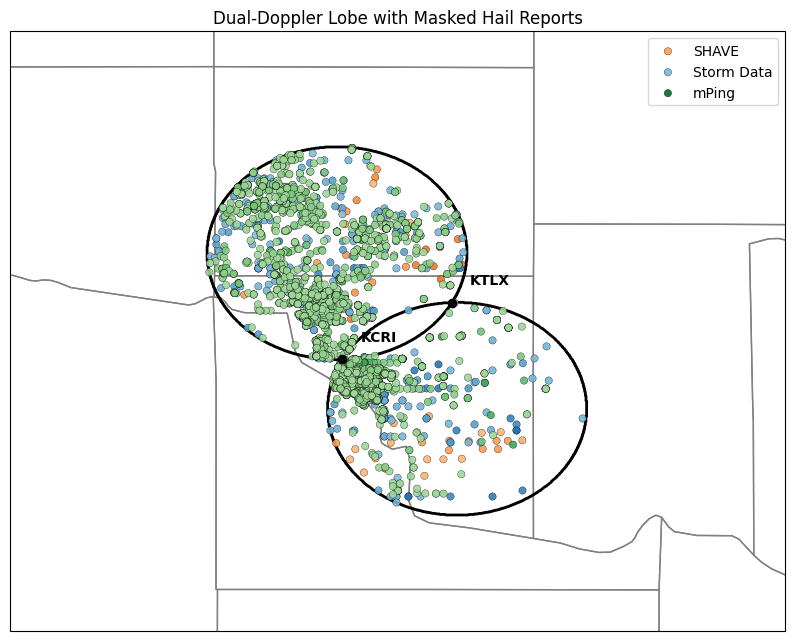

In [48]:
plot_reports = dda_region_reports.copy()

# Source styling
source_cmaps = {
    1: plt.cm.Oranges,  # SHAVE
    2: plt.cm.Blues,    # Storm Data
    3: plt.cm.Greens    # mPing
}
source_labels = {
    1: "SHAVE",
    2: "Storm Data",
    3: "mPing"
}

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.coastlines(resolution="10m", linewidth=0.5)

counties = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_2_counties",
    scale="10m",
    facecolor="none",
    edgecolor="gray",
    linewidth=1
)
ax.add_feature(counties, zorder=1)

# Lobe depiction (use contour for smooth boundary)
ax.contour(
    lon_grid, lat_grid, mask.astype(float),
    levels=[0.5], colors="black", linewidths=2,
    transform=ccrs.PlateCarree(), zorder=2
)

# Radar points + labels
# ax.plot(lon1, lat1, "ro", markersize=8, transform=ccrs.PlateCarree(), zorder=4)
# ax.plot(lon2, lat2, "bo", markersize=8, transform=ccrs.PlateCarree(), zorder=4)
# ax.text(lon1 + 0.03, lat1 + 0.03, "KTLX", color="red", fontsize=11, weight="bold",
#         transform=ccrs.PlateCarree(), zorder=5)
# ax.text(lon2 + 0.03, lat2 + 0.03, "KCRI", color="blue", fontsize=11, weight="bold",
#         transform=ccrs.PlateCarree(), zorder=5)

vmin = plot_reports["max_diameter_mm"].min()
vmax = plot_reports["max_diameter_mm"].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for src in sorted(plot_reports["source"].dropna().unique()):
    src = int(src)
    subset = plot_reports[plot_reports["source"] == src].copy()
    cmap = source_cmaps.get(src, plt.cm.Greys)

    # Larger hail -> darker shade (sample upper range of cmap)
    color_vals = 0.35 + 0.60 * norm(subset["max_diameter_mm"].values)
    point_colors = cmap(color_vals)

    ax.scatter(
        subset["lon"], subset["lat"],
        s=28, c=point_colors,
        label=source_labels.get(src, f"Source {src}"),
        edgecolors="black", linewidths=0.25, alpha=0.9,
        transform=ccrs.PlateCarree(), zorder=4
    )

for name, (lat, lon) in radars.items():
    ax.plot(lon, lat, "ko", markersize=6, transform=ccrs.PlateCarree(), zorder=4)
    ax.text(lon + 0.03, lat + 0.03, name, fontsize=10, weight="bold", transform=ccrs.PlateCarree(), zorder=5)

ax.set_extent([lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
              crs=ccrs.PlateCarree())
ax.set_title("Dual-Doppler Lobe with Masked Hail Reports")
ax.legend(loc="upper right")
plt.show()
fig.savefig(os.path.join(base_dir, f"DDA_lobe_hail_reports_KTLX_KCRI_{angle_thr}.png"), dpi=300, bbox_inches='tight')

In [49]:
import simplekml
import os
import pandas as pd
import matplotlib.pyplot as plt

def to_kml_when(ts):
    t = pd.to_datetime(ts, errors="coerce")
    if pd.isna(t):
        return None
    return t.strftime("%Y-%m-%dT%H:%M:%SZ")

kml = simplekml.Kml()

# 1) Add DDA lobe polygons from mask contour
lobe_folder = kml.newfolder(name="DDA Lobes")
cs = plt.contour(lon_grid, lat_grid, mask.astype(float), levels=[0.5])
segments = cs.allsegs[0]
plt.close()

for i, seg in enumerate(segments, start=1):
    if len(seg) < 3:
        continue

    coords = [(float(lon), float(lat)) for lon, lat in seg]
    if coords[0] != coords[-1]:
        coords.append(coords[0])

    pol = lobe_folder.newpolygon(name=f"DDA Lobe {i}")
    pol.outerboundaryis = coords
    pol.style.linestyle.color = simplekml.Color.black
    pol.style.linestyle.width = 2
    pol.style.polystyle.color = simplekml.Color.changealphaint(45, simplekml.Color.green)

# 2) Add masked hail reports
pts = kml.newfolder(name="Masked Hail Reports")

source_labels = {1: "SHAVE", 2: "Storm Data", 3: "mPing"}
source_kml_colors = {
    1: simplekml.Color.orange,
    2: simplekml.Color.blue,
    3: simplekml.Color.green
}

style_by_source = {}
for s, col in source_kml_colors.items():
    st = simplekml.Style()
    st.iconstyle.icon.href = "http://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
    st.iconstyle.color = col
    st.iconstyle.scale = 0.9
    st.labelstyle.scale = 0.8
    style_by_source[s] = st

for _, r in dda_region_reports.dropna(subset=["lon", "lat", "source", "time", "max_diameter_mm"]).iterrows():
    src = int(r["source"])
    src_label = source_labels.get(src, f"Source {src}")
    when = to_kml_when(r["time"])
    size_mm = float(r["max_diameter_mm"])

    p = pts.newpoint(
        name=f"{src_label} | {size_mm:.0f} mm | {pd.to_datetime(r['time']).strftime('%Y-%m-%d %H:%M:%S')}",
        coords=[(float(r["lon"]), float(r["lat"]))]
    )
    p.style = style_by_source.get(src, style_by_source[1])

    if when:
        p.timestamp = simplekml.TimeStamp(when=when)

    p.description = (
        f"Source: {src_label}\n"
        f"Time UTC: {pd.to_datetime(r['time']).strftime('%Y-%m-%d %H:%M:%S')}\n"
        f"max_diameter_mm: {size_mm:.1f}"
    )

out_kmz = os.path.join(base_dir, f"DDA_lobes_and_reports_TOKC_KTLX_KCRI_{angle_thr}.kmz")
kml.savekmz(out_kmz)
print(out_kmz)

C:\Users\wida0001\Documents\Courses\Weather Radar Applications\Data\Project\DDA_lobes_and_reports_TOKC_KTLX_KCRI_30.kmz


In [71]:
### Extract NEXRAD data for selected cases
from pathlib import Path
import datetime as dt
import re
import os
import urllib.request

import s3fs
import pandas as pd

NEXRAD_BUCKET = "unidata-nexrad-level2"
NEXRAD_HTTP_ROOT = f"https://{NEXRAD_BUCKET}.s3.amazonaws.com"
# Allow 4-character alphanumeric IDs (e.g., KTLX, NOP4, DAN1)
NEXRAD_KEY_RE = re.compile(r"([A-Z0-9]{4})(\d{8})_(\d{6})_V\d{2}")

RADAR_SITE_ALIASES = {
    "KCRI": ["KCRI", "NOP3", "NOP4", "ROP3", "ROP4", "FOP1", "DAN1", "DOP1"],
}

def _expand_radar_sites(site):
    site = str(site).upper()
    aliases = RADAR_SITE_ALIASES.get(site, [site])
    return list(dict.fromkeys(aliases))

def _parse_nexrad_key_time(key):
    name = Path(key).name
    match = NEXRAD_KEY_RE.search(name)
    if not match:
        return None
    return dt.datetime.strptime(f"{match.group(2)}{match.group(3)}", "%Y%m%d%H%M%S")

def _s3_to_https_url(s3_path):
    if s3_path.startswith("s3://"):
        path = s3_path[len("s3://"):]
    else:
        path = s3_path

    if path.startswith(f"{NEXRAD_BUCKET}/"):
        key = path[len(NEXRAD_BUCKET) + 1:]
    else:
        key = path
    return f"{NEXRAD_HTTP_ROOT}/{key}"

def _list_nexrad_keys_s3fs(aws, prefix):
    s3_dir = f"{NEXRAD_BUCKET}/{prefix}"
    try:
        items = aws.ls(s3_dir, refresh=True)
    except FileNotFoundError:
        return []
    except Exception as exc:
        print(f"Failed listing {s3_dir}: {exc}")
        return []

    keys = []
    for item in items:
        item_str = str(item)
        if item_str.startswith("s3://"):
            item_str = item_str[len("s3://"):]
        if item_str.startswith(f"{NEXRAD_BUCKET}/"):
            item_str = item_str[len(NEXRAD_BUCKET) + 1:]
        keys.append(item_str)
    return keys

def _download_nexrad_file(url, out_file):
    with urllib.request.urlopen(url) as response:
        with open(out_file, "wb") as out_f:
            out_f.write(response.read())

def build_time_windows_from_masked_counts(
    filtered_counts,
    dda_region_reports,
    selected_dates=None,
    time_col="time",
):
    reports = dda_region_reports.copy()
    reports[time_col] = pd.to_datetime(reports[time_col], errors="coerce")
    reports = reports.dropna(subset=[time_col]).copy()

    if selected_dates is None:
        dates = pd.to_datetime(filtered_counts.index).date
    else:
        dates = pd.to_datetime(selected_dates).date

    rows = []
    for day in dates:
        day_reports = reports.loc[reports[time_col].dt.date == day]
        if day_reports.empty:
            continue
        rows.append(
            {
                "date": pd.Timestamp(day).date(),
                "start_utc": day_reports[time_col].min().to_pydatetime(),
                "end_utc": day_reports[time_col].max().to_pydatetime(),
                "n_reports": int(len(day_reports)),
            }
        )

    if not rows:
        return pd.DataFrame(columns=["date", "start_utc", "end_utc", "n_reports"]).sort_values("date").reset_index(drop=True)

    return pd.DataFrame(rows).sort_values("start_utc").reset_index(drop=True)

def download_nexrad_from_aws_windows(
    windows,
    radar_sites,
    out_dir,
    skip_existing=True,
    include_mdm=False,
    dry_run=False,
    verbose=True,
):
    if isinstance(radar_sites, str):
        radar_sites = [radar_sites]
    if windows.empty:
        return pd.DataFrame(
            columns=["date", "radar", "archive_site", "scan_time_utc", "key", "local_file", "status"]
        )

    requested_sites = [site.upper() for site in radar_sites]
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    aws = s3fs.S3FileSystem(anon=True, client_kwargs={"region_name": "us-east-1"})

    records = []
    seen_keys = set()

    for _, row in windows.iterrows():
        start_utc = pd.to_datetime(row["start_utc"]).to_pydatetime()
        end_utc = pd.to_datetime(row["end_utc"]).to_pydatetime()

        for requested_site in requested_sites:
            archive_sites = _expand_radar_sites(requested_site)

            for archive_site in archive_sites:
                prefix = f"{start_utc:%Y/%m/%d}/{archive_site}"
                keys = _list_nexrad_keys_s3fs(aws, prefix)

                for key in keys:
                    if key in seen_keys:
                        continue
                    name = Path(key).name

                    if (not include_mdm) and ("MDM" in name):
                        continue
                    scan_time = _parse_nexrad_key_time(key)
                    if scan_time is None or not (start_utc <= scan_time <= end_utc):
                        continue

                    local_file = out_path / name
                    exists = local_file.exists()

                    if exists and skip_existing:
                        status = "exists_skipped"
                    elif dry_run:
                        status = "would_download"
                    else:
                        url = _s3_to_https_url(f"{NEXRAD_BUCKET}/{key}")
                        _download_nexrad_file(url, local_file)
                        status = "downloaded"

                    seen_keys.add(key)
                    records.append(
                        {
                            "date": row["date"],
                            "radar": requested_site,
                            "archive_site": archive_site,
                            "scan_time_utc": scan_time,
                            "key": key,
                            "local_file": str(local_file),
                            "status": status,
                        }
                    )

                    if verbose:
                        print(f"[{requested_site}/{archive_site}] {scan_time} -> {status}: {name}")

    if not records:
        return pd.DataFrame(
            columns=["date", "radar", "archive_site", "scan_time_utc", "key", "local_file", "status"]
        )
    return pd.DataFrame(records).sort_values("scan_time_utc").reset_index(drop=True)

def download_nexrad_from_filtered_counts(
    filtered_counts,
    dda_region_reports,
    selected_dates,
    radar_sites,
    out_dir,
    **download_kwargs,
):
    windows = build_time_windows_from_masked_counts(
        filtered_counts=filtered_counts,
        dda_region_reports=dda_region_reports,
        selected_dates=selected_dates,
    )
    manifest = download_nexrad_from_aws_windows(
        windows=windows,
        radar_sites=radar_sites,
        out_dir=out_dir,
        **download_kwargs,
    )
    return windows, manifest

dates = [
    "2013-05-19", "2013-05-30",
    "2023-04-19", "2023-04-20", "2025-05-25",
    "2020-08-31", "2020-05-04", "2024-09-24",
]
radar_sites = ["KTLX", "KCRI", "TOKC"]
radar_dir = os.path.join(base_dir, "NEXRAD")

windows, manifest = download_nexrad_from_filtered_counts(
    filtered_counts=filtered,
    dda_region_reports=dda_region_reports,
    selected_dates=dates,
    radar_sites=radar_sites,
    out_dir=radar_dir,
    skip_existing=True,
    dry_run=False,  # Set to False for actual downloading
    verbose=True,
)

print("\nTime windows derived from masked DDA reports:")
display(windows)
print("\nDownload manifest (preview):")
display(manifest.head(20))

[KTLX/KTLX] 2013-05-19 22:02:03 -> exists_skipped: KTLX20130519_220203_V06.gz
[KTLX/KTLX] 2013-05-19 22:06:17 -> exists_skipped: KTLX20130519_220617_V06.gz
[KTLX/KTLX] 2013-05-19 22:10:33 -> exists_skipped: KTLX20130519_221033_V06.gz
[KTLX/KTLX] 2013-05-19 22:14:50 -> exists_skipped: KTLX20130519_221450_V06.gz
[KTLX/KTLX] 2013-05-19 22:19:06 -> exists_skipped: KTLX20130519_221906_V06.gz
[KTLX/KTLX] 2013-05-19 22:23:22 -> exists_skipped: KTLX20130519_222322_V06.gz
[KTLX/KTLX] 2013-05-19 22:27:38 -> exists_skipped: KTLX20130519_222738_V06.gz
[KTLX/KTLX] 2013-05-19 22:31:53 -> exists_skipped: KTLX20130519_223153_V06.gz
[KTLX/KTLX] 2013-05-19 22:36:07 -> exists_skipped: KTLX20130519_223607_V06.gz
[KTLX/KTLX] 2013-05-19 22:40:25 -> exists_skipped: KTLX20130519_224025_V06.gz
[KTLX/KTLX] 2013-05-19 22:44:38 -> exists_skipped: KTLX20130519_224438_V06.gz
[KTLX/KTLX] 2013-05-19 22:48:56 -> exists_skipped: KTLX20130519_224856_V06.gz
[KTLX/KTLX] 2013-05-19 22:53:11 -> exists_skipped: KTLX20130519_

,date,start_utc,end_utc,n_reports
0,2013-05-19,2013-05-19 22:02:00,2013-05-19 23:59:00,57
1,2013-05-30,2013-05-30 20:45:00,2013-05-30 22:11:00,30
2,2020-05-04,2020-05-04 21:38:49,2020-05-04 23:27:18,46
3,2020-08-31,2020-08-31 22:13:37,2020-08-31 23:30:00,25
4,2023-04-19,2023-04-19 22:28:00,2023-04-19 23:59:00,38
5,2023-04-20,2023-04-20 00:12:00,2023-04-20 02:39:00,31
6,2024-09-24,2024-09-24 23:13:00,2024-09-24 23:59:00,15
7,2025-05-25,2025-05-25 22:33:00,2025-05-25 23:45:00,31



Download manifest (preview):


,date,radar,archive_site,scan_time_utc,key,local_file,status
0,2013-05-19,KTLX,KTLX,2013-05-19 22:02:03,2013/05/19/KTLX/KTLX20130519_220203_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
1,2013-05-19,KCRI,NOP4,2013-05-19 22:03:34,2013/05/19/NOP4/NOP420130519_220334_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,downloaded
2,2013-05-19,KTLX,KTLX,2013-05-19 22:06:17,2013/05/19/KTLX/KTLX20130519_220617_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
3,2013-05-19,KCRI,NOP4,2013-05-19 22:08:56,2013/05/19/NOP4/NOP420130519_220856_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,downloaded
4,2013-05-19,KTLX,KTLX,2013-05-19 22:10:33,2013/05/19/KTLX/KTLX20130519_221033_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
5,2013-05-19,KCRI,NOP4,2013-05-19 22:14:10,2013/05/19/NOP4/NOP420130519_221410_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,downloaded
6,2013-05-19,KTLX,KTLX,2013-05-19 22:14:50,2013/05/19/KTLX/KTLX20130519_221450_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
7,2013-05-19,KTLX,KTLX,2013-05-19 22:19:06,2013/05/19/KTLX/KTLX20130519_221906_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
8,2013-05-19,KCRI,NOP4,2013-05-19 22:19:32,2013/05/19/NOP4/NOP420130519_221932_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,downloaded
9,2013-05-19,KTLX,KTLX,2013-05-19 22:23:22,2013/05/19/KTLX/KTLX20130519_222322_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped


In [ ]:
### Grid settings

default_ymin, default_ymax = -100, 100
default_xmin, default_xmax = -100, 100

xlims = (default_xmin*1000, default_xmax*1000)
ylim = (default_ymin*1000, default_ymax*1000)
zlims = (0, 20000) # to 20 km AGL

# Radius of influence
roi = 1000.0 # meters

# Define number of grid points (Nz, Ny, Nx)
x_gridpoints = int(default_xmax - default_xmin) + 1
y_gridpoints = int(default_ymax - default_ymin) + 1
z_gridpoints = 21

grid_shape = (z_gridpoints, y_gridpoints, x_gridpoints)

In [ ]:
### Data processing ###
radar_alias = []
archive_sites = [_expand_radar_sites(r) for r in radar_sites]
radar_alias.extend(archive_sites[i][j] for i in range(len(archive_sites)) for j in range(len(archive_sites[i]))) 
print("Radar aliases:", radar_alias)

# Process each date and radar separately (150-250 MB each) to avoid memory issues
for date in dates:
    # Iterate through each radar site
    for site in radar_alias:
        files = [f for f in os.listdir(radar_dir) if f.startswith(f"{site}{date.replace('-', '')}")]
        print(f"Processing {len(files)} files for {site} on {date}...")

        radars = [pyart.io.read(os.path.join(radar_dir, f)) for f in files]
        print(radars[0].info())
        display = pyart.graph.RadarDisplay(radars[0])

    ## Apply gatefilter
    gfilters = [pyart.correct.GateFilter(radar) for radar in radars]
    [gfilter.exclude_below("reflectivity", 0) for gfilter in gfilters]
    [gfilter.exclude_below("cross_correlation_ratio", 0.5) for gfilter in gfilters]
    
    ## Calculate KDP
    kdp_dict = [pyart.retrieve.kdp_vulpiani(radar, gatefilter=gfilter, 
                                            band='C' if radar.metadata.get('instrument_name', '').startswith('T') else 'S',
                                            windsize=10, n_iter=2, interp=False) for radar, gfilter in zip(radars, gfilters)]
    [radar.add_field('specific_differential_phase', kdp_dict[i][0], replace_existing=True) for i, radar in enumerate(radars)]

    ## Velocity dealiasing
    dealiased_radars = [pyart.correct.dealias_region_based(radar, vel_field='velocity', nyquist_vel=radar.instrument_parameters['nyquist_velocity']['data'][0], centered=True, gatefilter=gfilter) for radar, gfilter in zip(radars, gfilters)]
    [radar.add_field('corrected_velocity', dealiased_radars[i].fields['velocity'], replace_existing=True) for i, radar in enumerate(radars)]

    # Two-pass Barnes interpolation scheme
    grid_barnes2 = [pyart.map.grid_from_radars(
        radar,
        grid_shape=grid_shape,
        gridding_algo = 'map_gates_to_grid',
        weighting_function = 'barnes2',
        gatefilters = gfilter,
        roi_func = roi,
        constant_roi = roi,
        grid_limits=(zlims, ylim, xlims)) for radar, gfilter in zip(radars, gfilters)]
    
    print(radars[0].info())

print(f"Processed radars for {len(dates)} dates.")

['KTLX', 'KCRI', 'NOP3', 'NOP4', 'ROP3', 'ROP4', 'FOP1', 'DAN1', 'DOP1', 'TOKC']
2013-05-19: 50 files
altitude:
	data: <ndarray of type: float64 and shape: (1,)>
	long_name: Altitude
	standard_name: Altitude
	units: meters
	positive: up
altitude_agl: None
antenna_transition: None
azimuth:
	data: <ndarray of type: float64 and shape: (8280,)>
	units: degrees
	standard_name: beam_azimuth_angle
	long_name: azimuth_angle_from_true_north
	axis: radial_azimuth_coordinate
	comment: Azimuth of antenna relative to true north
elevation:
	data: <ndarray of type: float32 and shape: (8280,)>
	units: degrees
	standard_name: beam_elevation_angle
	long_name: elevation_angle_from_horizontal_plane
	axis: radial_elevation_coordinate
	comment: Elevation of antenna relative to the horizontal plane
fields:
	spectrum_width:
		data: <ndarray of type: float32 and shape: (8280, 1832)>
		units: meters_per_second
		standard_name: doppler_spectrum_width
		long_name: Spectrum Width
		valid_max: 63.0
		valid_min: -63

KeyboardInterrupt: 

In [ ]:
### Grid data into Cartesian coordinates

